<a href="https://colab.research.google.com/github/GeethmaMunasinghe/Digital_Image_Processing/blob/main/Basic_Intensity_Transformation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.autolayout"]=True


In [ ]:

img=cv2.imread('Fig0304(a)(breast_digital_Xray).tif')


In [ ]:

def negative(r):
  s=255-r
  return s


In [ ]:
x_values=np.linspace(0,255,500)
y_values=negative(x_values)

plt.plot(x_values,y_values)
plt.xlabel('Input Intensity Levels')
plt.ylabel('Output Intensity Levels')


In [ ]:

img_neg=negative(img)


In [ ]:

plt.imshow(img)


In [ ]:

plt.imshow(img_neg)


In [37]:

def scale_image(input_img):
  input_img=input_img/np.max(input_img)
  input_img=(input_img*255).astype('int')
  return input_img

def plot_results(input_img,output_img,x_values,y_values,save_as):
  #plotting the graph
  plt.figure(figsize=(36,12))

  plt.subplot(131)
  plt.imshow(input_img)
  plt.title('Input Image')
  plt.axis('off')

  plt.subplot(132)
  plt.plot(x_values,y_values)
  plt.xlabel('Input pixels')
  plt.ylabel('Output pixels')
  plt.grid(True)

  plt.subplot(133)
  plt.imshow(output_img)
  plt.title('Transformed image')
  plt.axis('off')

  plt.savefig(save_as + '.png')


In [ ]:

plot_results(img,img_neg,x_values,y_values,'Negative')



Log Transformation


In [ ]:
im=cv2.imread('Fig0305(a)(DFT_no_log).tif')


In [ ]:

def logTransformation(r,c=1):
  s= c * np.log(1.0+r)
  return s


In [ ]:

img_log=logTransformation(im)
img_log_scaled=scale_image(img_log)


In [ ]:
x_values=np.linspace(0,255,500)
y_values=logTransformation(x_values)

plot_results(im,img_log_scaled,x_values,y_values,'log')




**Gamma Trasformation**

In [2]:
spine_img=cv2.imread("Fig0308(a)(fractured_spine).tif")


(-0.5, 745.5, 975.5, -0.5)

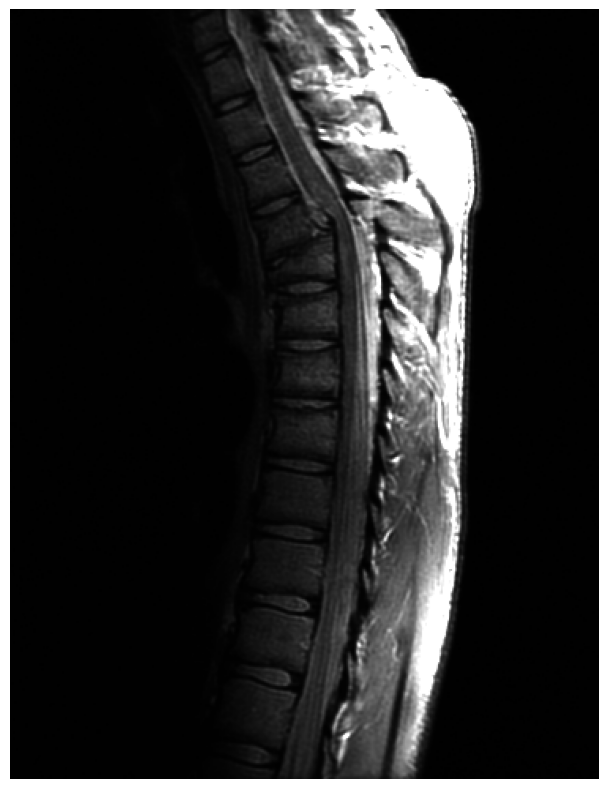

In [3]:

plt.figure(figsize=(12,8))
plt.imshow(spine_img)
plt.axis('off')



In [6]:

def gammaTransforma(r,gamma,c=1):
  s=c*(r**gamma)
  return s


In [9]:

img_gamma=gammaTransforma(spine_img,0.4)
img_gamma_scaled=scale_image(img_gamma)


In [ ]:

x_valuess=np.linspace(0,255,500)
y_valuess=gammaTransforma(x_valuess,0.4)

plot_results(spine_img,img_gamma_scaled,x_valuess,y_valuess,"gamma_0.4")


In [11]:

def performGammaTransform(input_img,gammaValue):
  img_gamma=gammaTransforma(input_img,gammaValue)
  img_gamma_scaled=scale_image(img_gamma)

  x_values=np.linspace(0,255,500)
  y_values=gammaTransforma(x_values,gammaValue)

  plot_results(input_img,img_gamma_scaled,x_values,y_values,"gamma"+str(gammaValue))

  return img_gamma_scaled


In [ ]:
final_images=[]

for gammaValue in [0.6,0.4,0.3]:
  final_images.append(performGammaTransform(spine_img,gammaValue))


**Gamma>1**

In [13]:
arial_img=cv2.imread("Fig0309(a)(washed_out_aerial_image).tif")


(-0.5, 764.5, 768.5, -0.5)

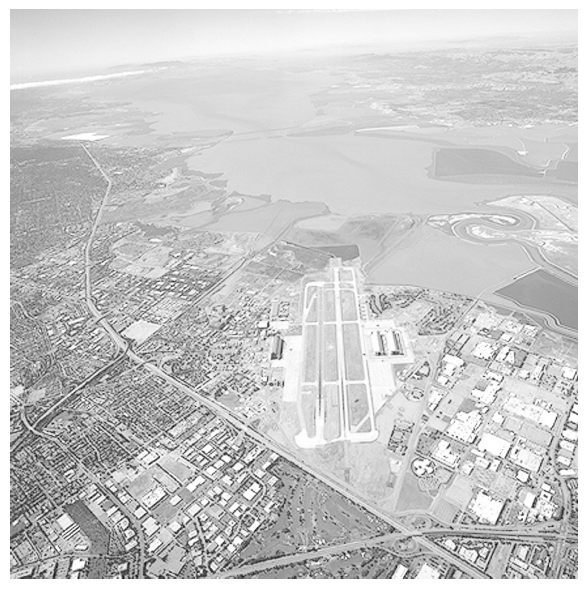

In [15]:

plt.figure(figsize=(10,6))
plt.imshow(arial_img)
plt.axis('off')


In [ ]:
final_image_arial=[]

for gammaValue in [3.0,4.0,5.0]:
  final_images.append(performGammaTransform(arial_img,gammaValue))



# **Contrast Stretching**


In [17]:

im=cv2.imread("Fig0310(b)(washed_out_pollen_image).tif")


(-0.5, 888.5, 888.5, -0.5)

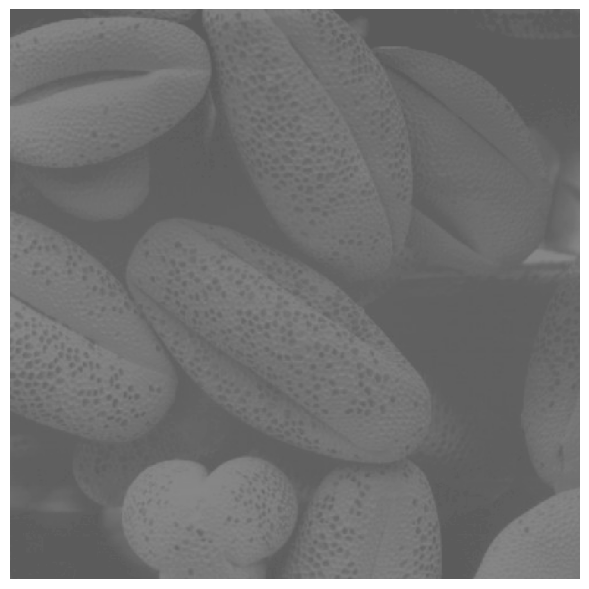

In [18]:

plt.figure(figsize=(10,6))
plt.imshow(im)
plt.axis('off')


In [31]:

def piecewiseLinear(r,r1,s1,r2,s2):
  if r<r1:
    s=(s1/r1)*r
  elif r>r1 and r<r2:
    s=((s2-s1)/(r2-r1)) * (r-r1) + s1
  else:
    s=((255-s2)/(255-r2)) * (r-r2)+s2
  return int(s)

In [33]:

piecewiseLinearVec=np.vectorize(piecewiseLinear)


In [34]:

x_values5=np.linspace(0,255,500)
y_values5=piecewiseLinearVec(x_values5,80,30,150,190)


In [35]:

transformed_im=piecewiseLinearVec(im,80,30,150,190)


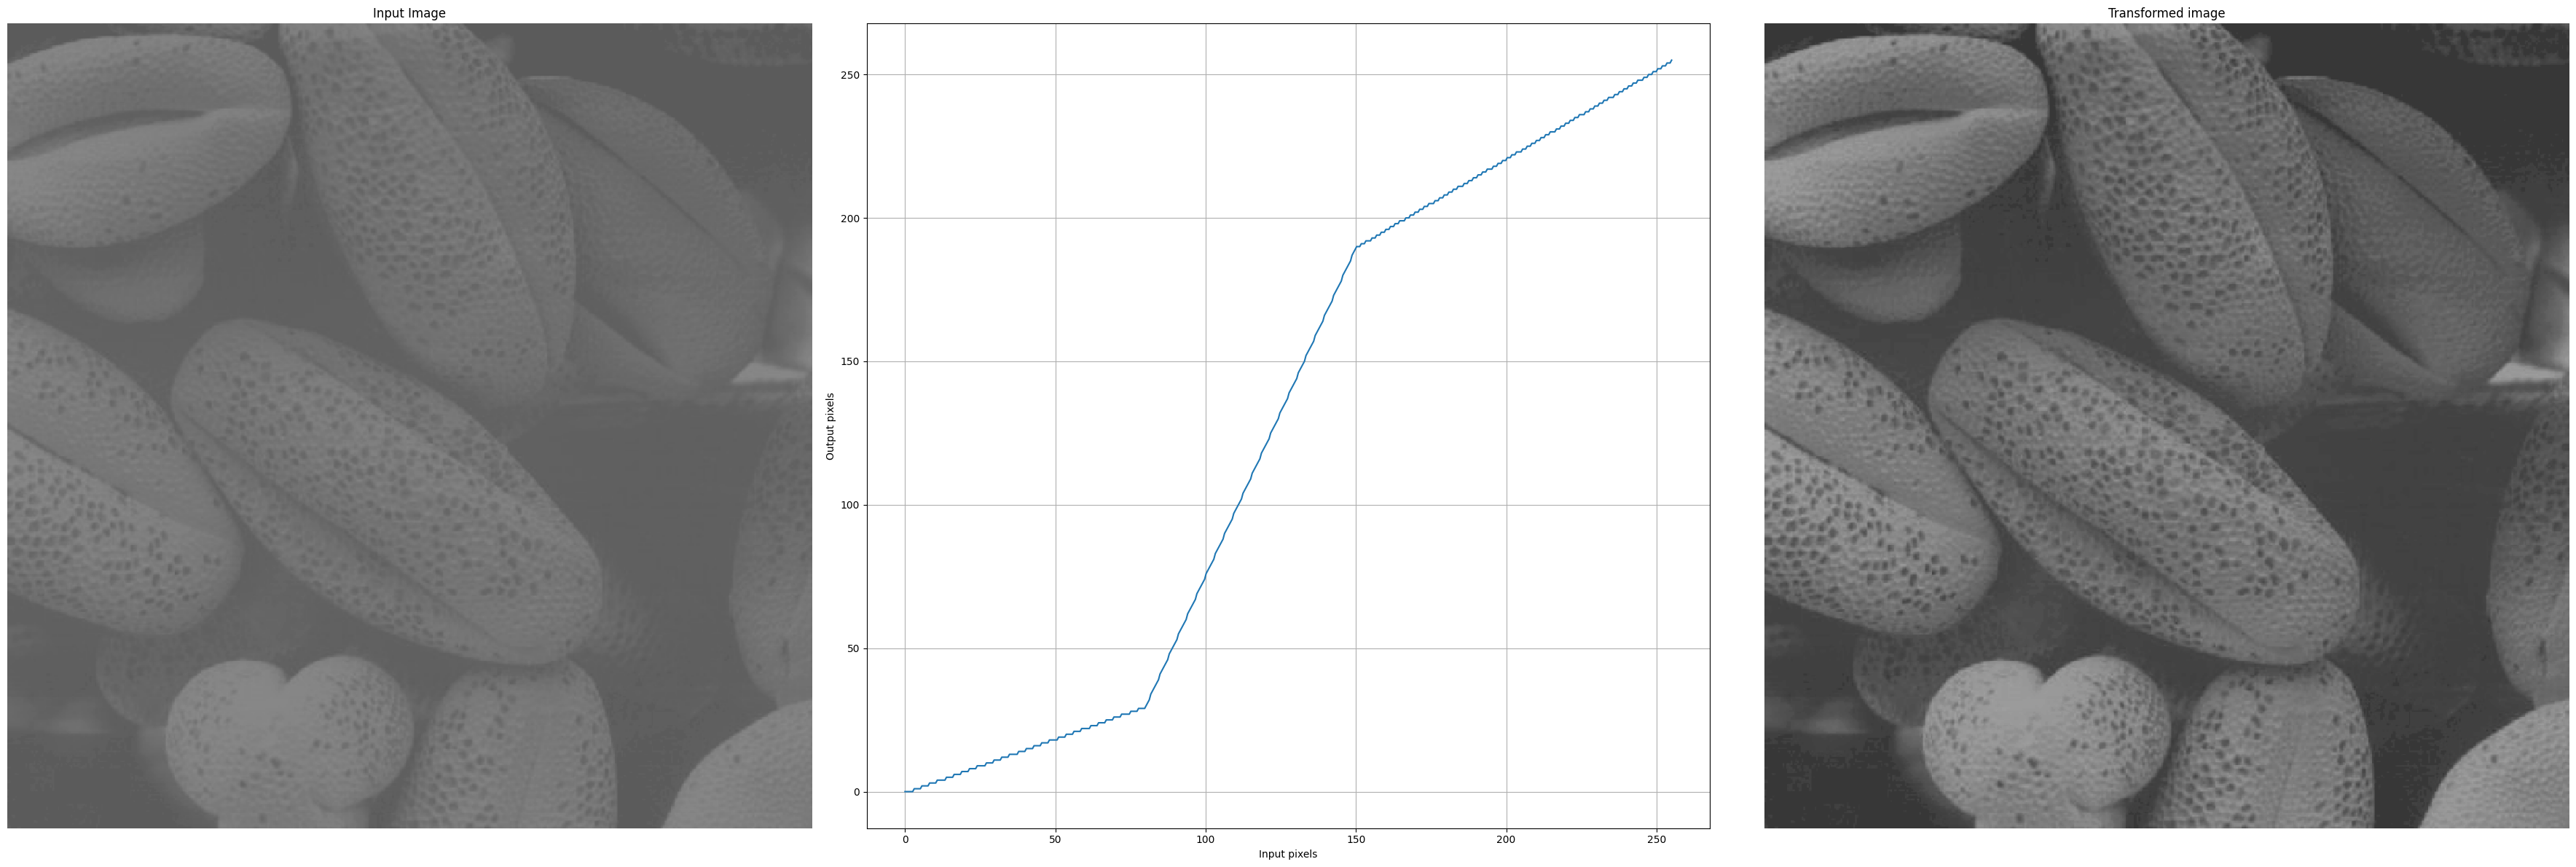

In [38]:

plot_results(im,transformed_im,x_values5,y_values5,"piecewise_linear")


In [39]:

m=np.mean(im)
transformed_im2=piecewiseLinearVec(im,m,0,m,255)


In [40]:

x_values5=np.linspace(0,255,500)
y_values5=piecewiseLinearVec(x_values5,m,0,m,255)


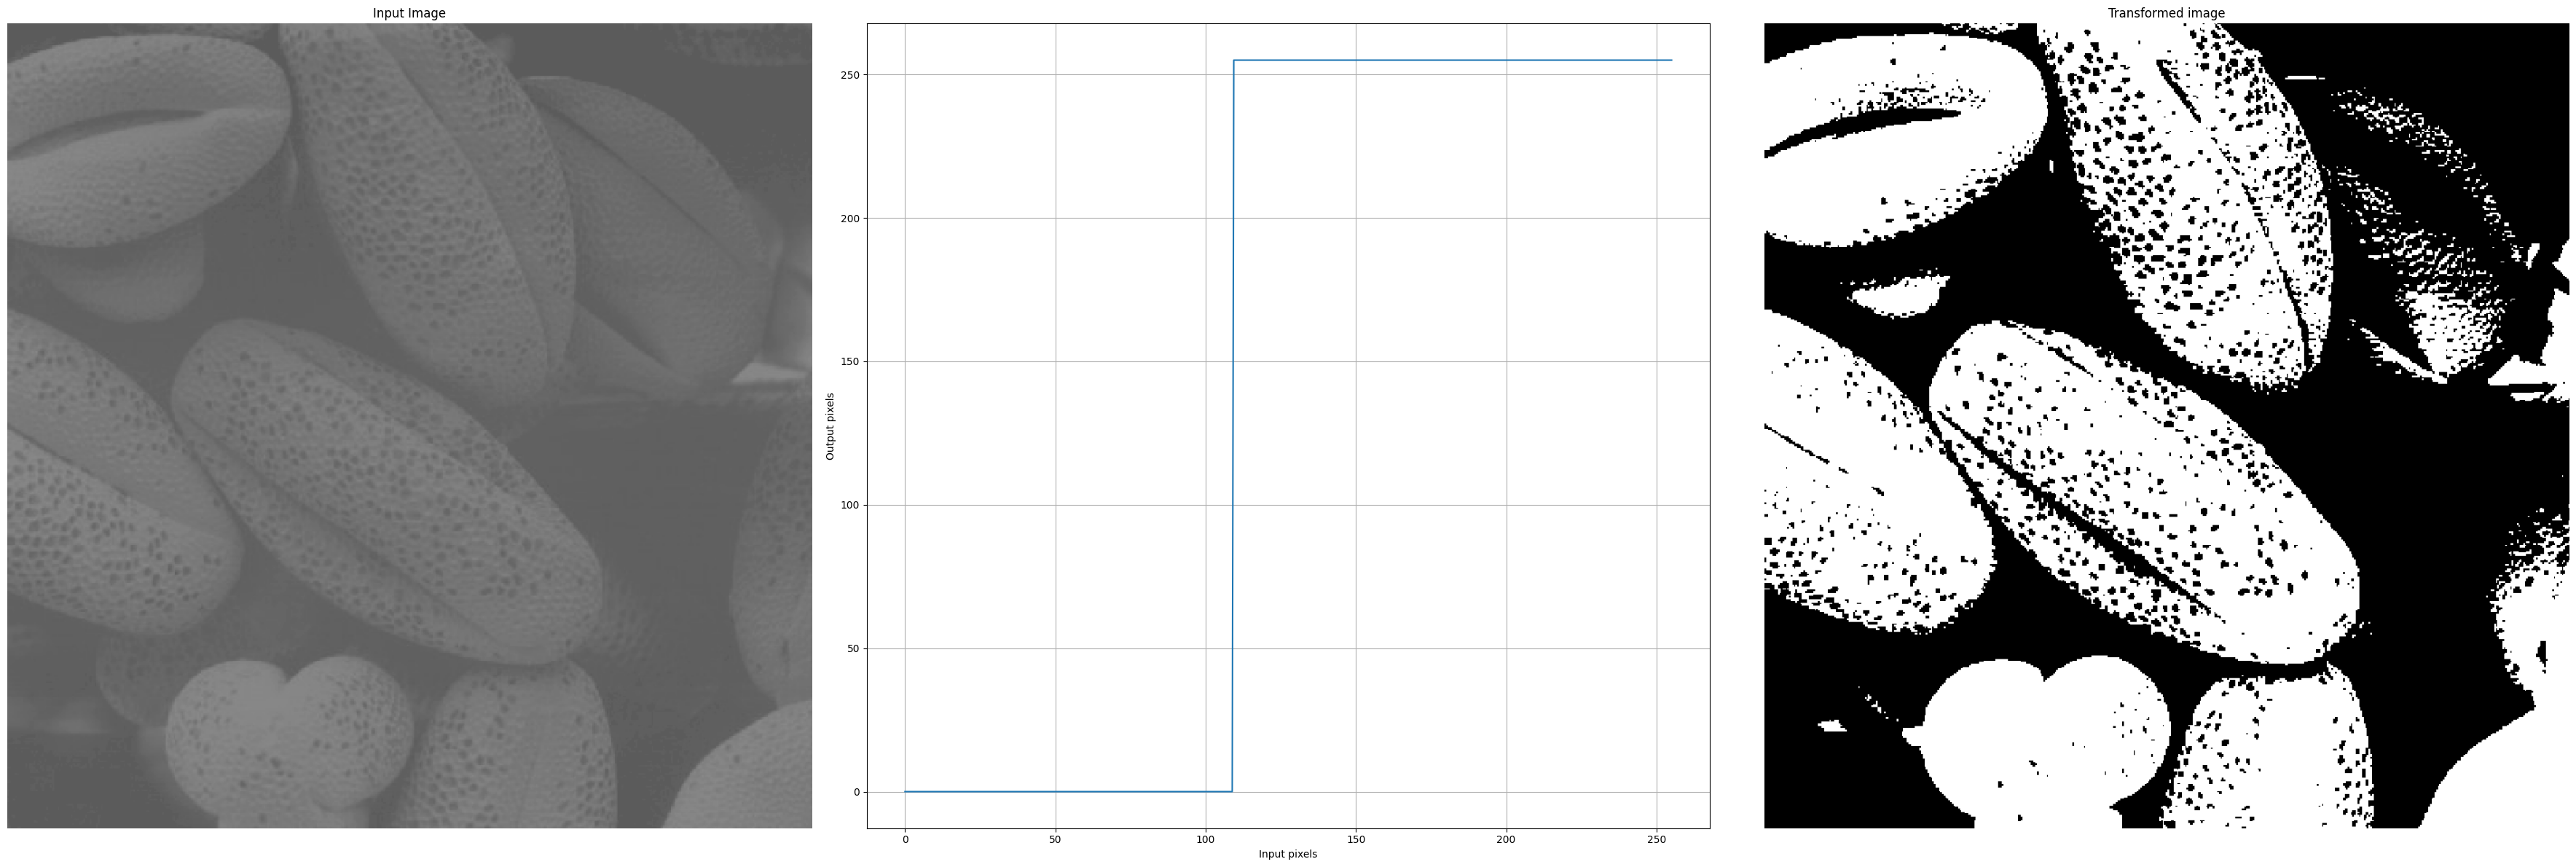

In [42]:
plot_results(im,transformed_im2,x_values5,y_values5,"piecewise_linear_mean")

# Intensity level slicing

In [43]:

kidney_img=cv2.imread("Fig0312(a)(kidney).tif")


(-0.5, 719.5, 827.5, -0.5)

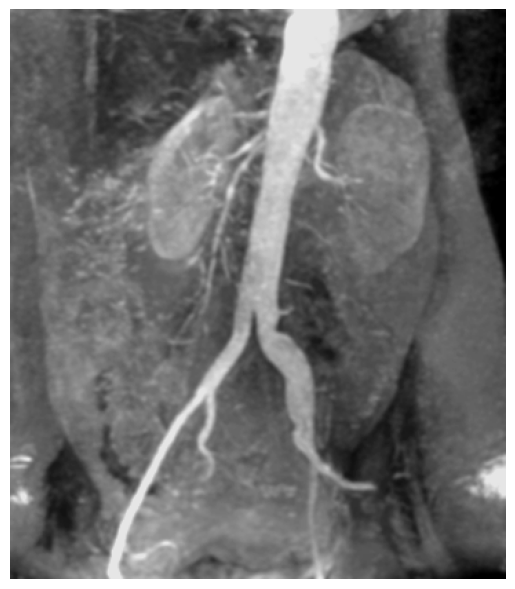

In [45]:
plt.figure(figsize=(10,6))
plt.imshow(kidney_img)
plt.axis('off')

In [46]:
def intensityLevelTransform2(r):
  if r>140 and 4<210:
    return 240
  else:
    return r


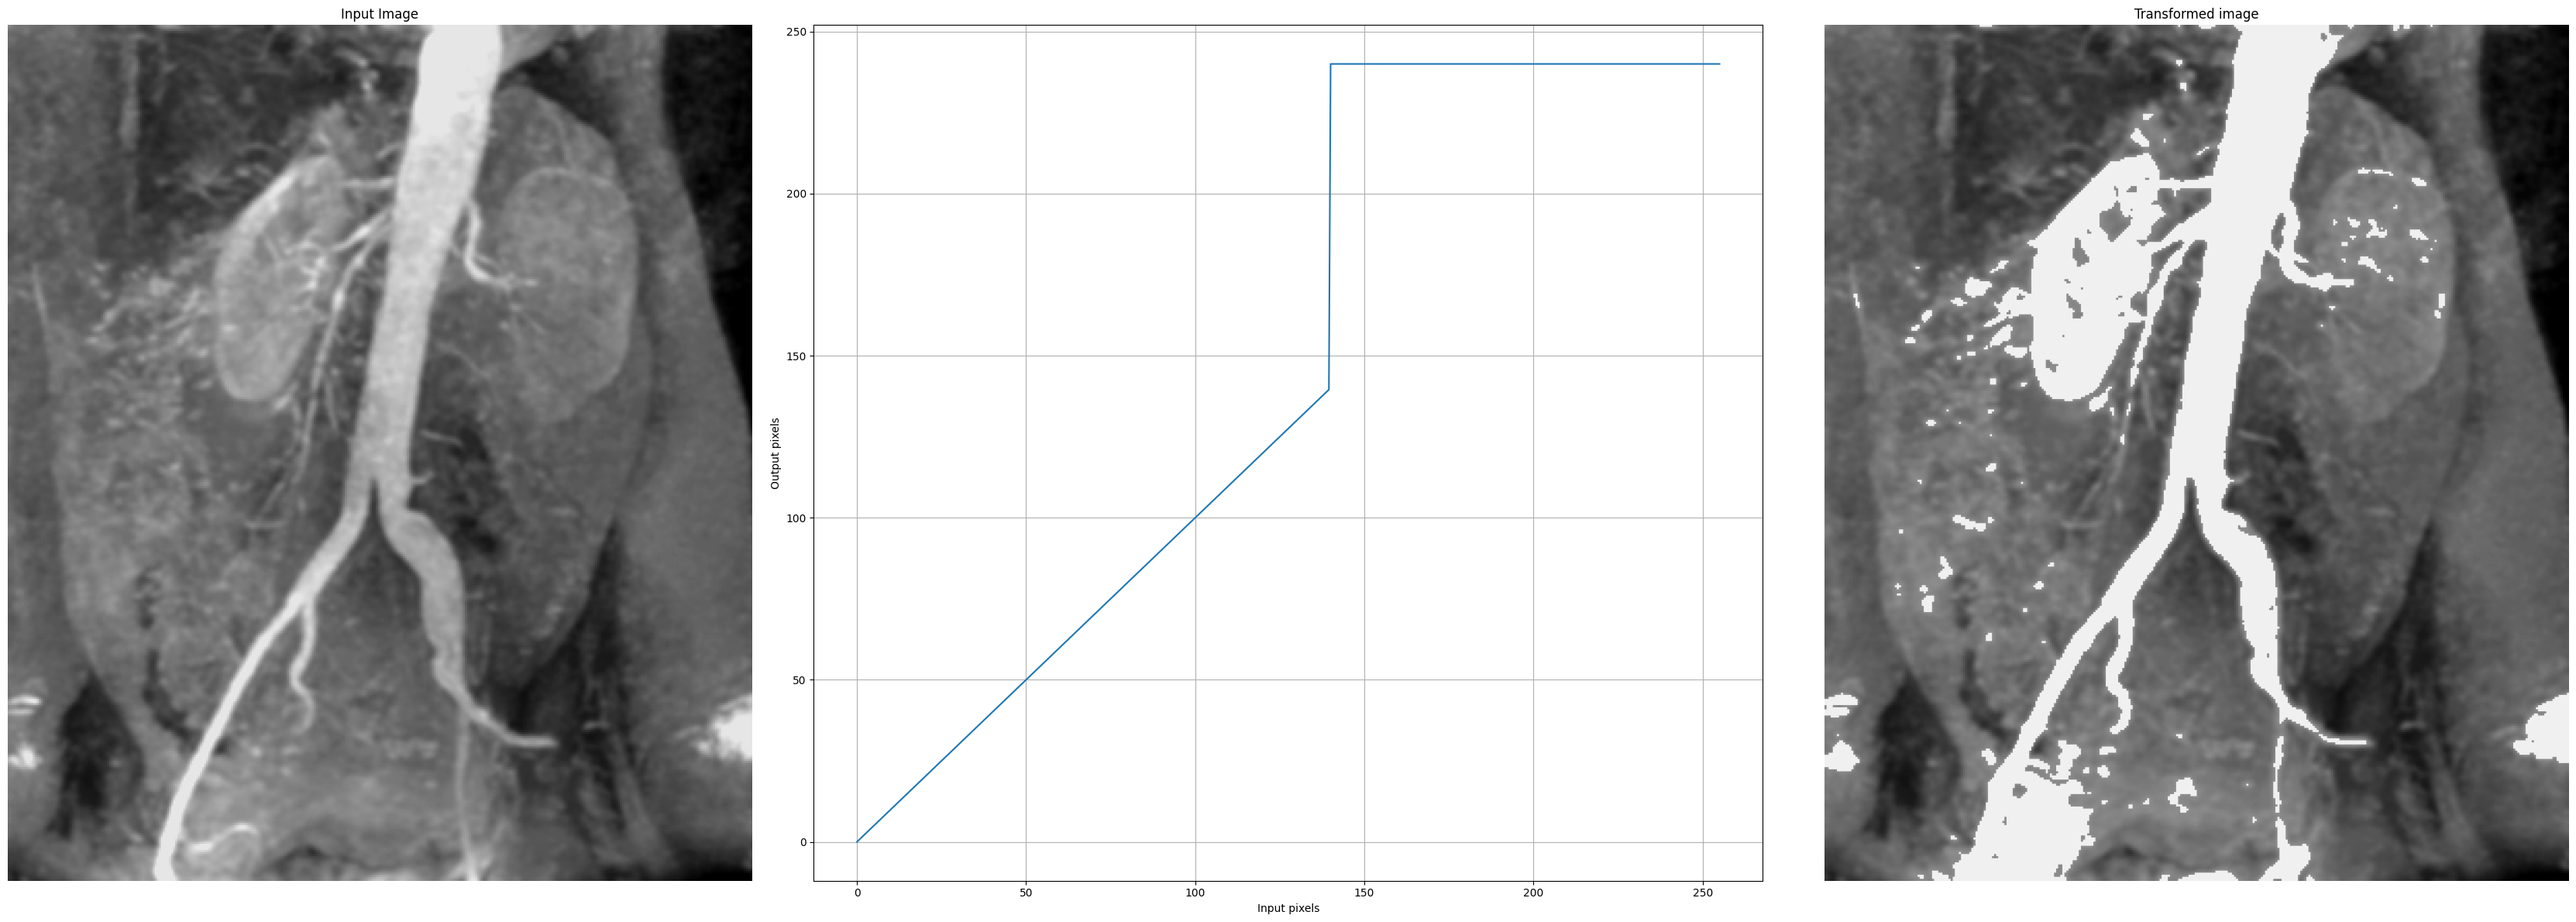

In [47]:

intensityLevelTransform2vec=np.vectorize(intensityLevelTransform2)

trnsform2=intensityLevelTransform2vec(kidney_img)

x_values=np.linspace(0,255,500)
y_values=intensityLevelTransform2vec(x_values)

plot_results(kidney_img,trnsform2,x_values,y_values,"intensity_level_transform_2")
